## Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import Libraries

In [ ]:
import os
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score, precision_score

## Setup and Environment Mode

**Note:** Please modify the paths below to the your own paths, and change the experiment tag (segmentation or w/o segmentation).

In [ ]:
# For raw data experiment
IMG_PARENT_DIR = '/content/drive/MyDrive/Wound_Assessment/data/original_data_and_mask/Images/'
PUBLIC_IMG_DIR = os.path.join(IMG_PARENT_DIR, 'unlabelled_2609')
PRIVATE_IMG_DIR = os.path.join(IMG_PARENT_DIR, 'labelled_107')
EXPERIMENT_NAME = "baseline_without_segmentation"

# For segmented experiment, change to:
# IMG_PARENT_DIR = '../data/segmented_images/Segmented_Dataset_Final_v2'
# EXPERIMENT_NAME = "baseline_with_segmentation"

CSV_PATH = '/content/drive/MyDrive/Wound_Assessment/data/metadata/metadata_with_folds.csv'

df = pd.read_csv(CSV_PATH)

print(f"Running experiment: {EXPERIMENT_NAME}")
print(f"Total images: {len(df)}")

SAVE_DIR = f"/content/drive/MyDrive/Wound_Assessment/results/{EXPERIMENT_NAME}"
MODEL_SAVE_DIR = os.path.join(SAVE_DIR, "models")
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

Running experiment: baseline_without_segmentation
Total images: 107


## Preprocessing Functions

In [ ]:
TARGET_SIZE = 224

def resize_with_padding(image, target_size=224):
    h, w = image.shape[:2]
    scale = min(target_size / w, target_size / h)
    new_w, new_h = int(w * scale), int(h * scale)
    resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
    canvas = np.zeros((target_size, target_size, 3), dtype=np.uint8)
    x_off, y_off = (target_size - new_w) // 2, (target_size - new_h) // 2
    canvas[y_off:y_off+new_h, x_off:x_off+new_w] = resized

    return canvas

def find_image_path(base_name):
    possible_paths = [
        # Case 1: segmented images directly inside IMG_PARENT_DIR
        os.path.join(IMG_PARENT_DIR, base_name + ".jpg"),
        os.path.join(IMG_PARENT_DIR, base_name + ".png"),
        os.path.join(IMG_PARENT_DIR, base_name + ".jpeg"),

        # Case 2: raw images separated into Public_Dataset and Real_World_Dataset
        os.path.join(PUBLIC_IMG_DIR, base_name + ".jpg"),
        os.path.join(PUBLIC_IMG_DIR, base_name + ".png"),
        os.path.join(PUBLIC_IMG_DIR, base_name + ".jpeg"),

        os.path.join(PRIVATE_IMG_DIR, base_name + ".jpg"),
        os.path.join(PRIVATE_IMG_DIR, base_name + ".png"),
        os.path.join(PRIVATE_IMG_DIR, base_name + ".jpeg"),
    ]

    for path in possible_paths:
        if os.path.exists(path):
            return path

    return None

## Data Augmentation and Normalization

In [ ]:
data_transforms = {
    'train': transforms.Compose([
        # Data Augmentation
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),

        # Formatting
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),

    'val': transforms.Compose([
        # Standardize
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

## Dataset Class

In [ ]:
class ProposedWoundDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = str(row['filename']).strip()
        base_name = os.path.splitext(filename)[0]

        # Load image from selected IMG_PARENT_DIR
        img_path = find_image_path(base_name)

        if img_path is None:
            print(f"Warning: Image not found for {filename}. Using blank image.")
            image_cv = np.zeros((TARGET_SIZE, TARGET_SIZE, 3), dtype=np.uint8)
        else:
            image_cv = cv2.imread(img_path)

            if image_cv is None:
                print(f"Warning: Unable to read {img_path}. Using blank image.")
                image_cv = np.zeros((TARGET_SIZE, TARGET_SIZE, 3), dtype=np.uint8)
            else:
                # Apply resize with padding so both raw and segmented inputs are 224x224
                image_cv = resize_with_padding(image_cv, TARGET_SIZE)

        # Convert BGR OpenCV image to RGB PIL image
        image = Image.fromarray(cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB))

        if self.transform:
            image = self.transform(image)

        # -1 means missing annotation and will be ignored by loss/metrics
        inf = torch.tensor(int(row['Final_Inf']), dtype=torch.long)
        moist = torch.tensor(int(row['Final_Moist']), dtype=torch.long)
        edge = torch.tensor(int(row['Final_Edge']), dtype=torch.long)

        return image, inf, moist, edge

## Calculate Class Weights

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
def calculate_task_weights(df, column_name, num_classes):

    # Calculate class weights while ignoring -1 missing labels.
    valid_data = df[df[column_name] != -1][column_name].astype(int).values

    class_counts = np.bincount(valid_data, minlength=num_classes)
    num_samples = class_counts.sum()

    weights = np.ones(num_classes, dtype=np.float32)
    for i in range(num_classes):
        if class_counts[i] > 0:
            weights[i] = num_samples / (num_classes * class_counts[i])
        else:
            weights[i] = 0.0

    return torch.tensor(weights, dtype=torch.float).to(DEVICE)

# Calculate weights for all 3 tasks
weights_inf = calculate_task_weights(df, 'Final_Inf', 2)
weights_moist = calculate_task_weights(df, 'Final_Moist', 3)
weights_edge = calculate_task_weights(df, 'Final_Edge', 2)

print(f"Infection Weights (Non-Infected vs Infected): {weights_inf}")
print(f"Moisture Weights (Dry vs Moist vs Wet): {weights_moist}")
print(f"Edge Weights (Not Advancing vs Advancing): {weights_edge}")

Infection Weights (Non-Infected vs Infected): tensor([0.7465, 1.5143])
Moisture Weights (Dry vs Moist vs Wet): tensor([2.7436, 0.4573, 2.2292])
Edge Weights (Not Advancing vs Advancing): tensor([1.7000, 0.7083])


## Define Multi-Task Model Architecture

In [ ]:
class ProposedMultiTaskModel(nn.Module):
    def __init__(self):
        super(ProposedMultiTaskModel, self).__init__()

        # Load EfficientNet-B0 with Pre-trained Weights
        self.backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

        # Extract the number of input features going into the classifier
        num_ftrs = self.backbone.classifier[1].in_features

        # Remove the original single-task classifier
        self.backbone.classifier = nn.Identity()

        # Define 3 separate 'Heads' for your T.I.M.E. tasks
        # Infection Head
        self.head_inf = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 2)   # Infection (0=Not Infected, 1=Infected)
        )

        # Moisture Head
        self.head_moist = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 3)   # Moisture (0=Dry, 1=Moist, 2=Wet)
        )

        # Edge Head
        self.head_edge = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 2)   # Edge (0=Not Advancing, 1=Advancing)
        )

    def forward(self, x):
        # Feature extraction
        features = self.backbone(x)

        # Multi-task outputs
        out_inf = self.head_inf(features)
        out_moist = self.head_moist(features)
        out_edge = self.head_edge(features)

        return out_inf, out_moist, out_edge

print(" Multi-Task EfficientNet-B0 architecture defined.")

 Multi-Task EfficientNet-B0 architecture defined.


## Weighted Loss

In [ ]:
# Weighted Cross-Entropy (For Imbalance)
criterion_inf = nn.CrossEntropyLoss(weight=weights_inf, ignore_index=-1)
criterion_moist = nn.CrossEntropyLoss(weight=weights_moist, ignore_index=-1)
criterion_edge = nn.CrossEntropyLoss(weight=weights_edge, ignore_index=-1)

## Training and Validation Functions

In [ ]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0

    for images, inf_labels, moist_labels, edge_labels in loader:
        images = images.to(device)
        inf_labels = inf_labels.to(device)
        moist_labels = moist_labels.to(device)
        edge_labels = edge_labels.to(device)

        optimizer.zero_grad()

        # Forward pass
        out_inf, out_moist, out_edge = model(images)

        # Calculate losses
        loss_inf = criterion_inf(out_inf, inf_labels)
        loss_moist = criterion_moist(out_moist, moist_labels)
        loss_edge = criterion_edge(out_edge, edge_labels)

        # Combined Loss (Multi-Task Learning)
        batch_loss = loss_inf + loss_moist + loss_edge

        batch_loss.backward()
        optimizer.step()

        total_loss += batch_loss.item()

    return total_loss / len(loader)

In [ ]:
def validate_one_epoch(model, loader, device):
    model.eval()
    results = {
        'inf': {'preds': [], 'labels': []},
        'moist': {'preds': [], 'labels': []},
        'edge': {'preds': [], 'labels': []}
    }

    val_loss = 0

    with torch.no_grad():
        for images, inf_l, moist_l, edge_l in loader:
            images = images.to(device)
            inf_l = inf_l.to(device)
            moist_l = moist_l.to(device)
            edge_l = edge_l.to(device)

            # Forward pass
            out_inf, out_moist, out_edge = model(images)

            # Calculate validation loss using same criteria as training
            loss_inf = criterion_inf(out_inf, inf_l)
            loss_moist = criterion_moist(out_moist, moist_l)
            loss_edge = criterion_edge(out_edge, edge_l)
            val_loss += (loss_inf + loss_moist + loss_edge).item()

            # Extract outputs for metric calculation
            tasks = ['inf', 'moist', 'edge']
            outputs = [out_inf, out_moist, out_edge]
            labels_list = [inf_l, moist_l, edge_l]

            for task, output, labels in zip(tasks, outputs, labels_list):
                preds = torch.argmax(output, dim=1).cpu().numpy()
                lbls = labels.cpu().numpy()

                # Filter out -1 missing labels
                mask = lbls != -1
                results[task]['preds'].extend(preds[mask])
                results[task]['labels'].extend(lbls[mask])

    # Calculate Macro metrics to handle imbalanced data
    metrics = {'loss': val_loss / len(loader)}
    for task in ['inf', 'moist', 'edge']:
        metrics[f'f1_{task}'] = f1_score(
            results[task]['labels'], results[task]['preds'],
            average='macro', zero_division=0
        )
        metrics[f'recall_{task}'] = recall_score(
            results[task]['labels'], results[task]['preds'],
            average='macro', zero_division=0
        )
        metrics[f'precision_{task}'] = precision_score(
            results[task]['labels'], results[task]['preds'],
            average='macro', zero_division=0
        )

    return metrics

## 5-Fold Cross Validation

In [ ]:
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
NUM_EPOCHS = 15
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def calculate_task_weights(df, column_name, num_classes):

    # Calculate class weights while ignoring -1 missing labels.
    valid_data = df[df[column_name] != -1][column_name].astype(int).values

    class_counts = np.bincount(valid_data, minlength=num_classes)
    num_samples = class_counts.sum()

    weights = np.ones(num_classes, dtype=np.float32)
    for i in range(num_classes):
        if class_counts[i] > 0:
            weights[i] = num_samples / (num_classes * class_counts[i])
        else:
            weights[i] = 0.0

    return torch.tensor(weights, dtype=torch.float).to(DEVICE)

# Calculate weights for all 3 tasks
weights_inf = calculate_task_weights(df, 'Final_Inf', 2)
weights_moist = calculate_task_weights(df, 'Final_Moist', 3)
weights_edge = calculate_task_weights(df, 'Final_Edge', 2)

# Weighted Cross-Entropy (For Imbalance)
criterion_inf = nn.CrossEntropyLoss(weight=weights_inf, ignore_index=-1)
criterion_moist = nn.CrossEntropyLoss(weight=weights_moist, ignore_index=-1)
criterion_edge = nn.CrossEntropyLoss(weight=weights_edge, ignore_index=-1)

print(f"Starting Supervised Training for {EXPERIMENT_NAME} on Device: {DEVICE}")

# Store results for all tasks across all 5 folds
fold_metrics_summary = []

for fold in range(5):
    print(f" STARTING FOLD {fold+1}/5 ")

    # 1. Split Data
    train_df = df[df['fold'] != fold].reset_index(drop=True)
    val_df = df[df['fold'] == fold].reset_index(drop=True)

    # 2. Loaders
    train_ds = ProposedWoundDataset(train_df, transform=data_transforms['train'])
    val_ds = ProposedWoundDataset(val_df, transform=data_transforms['val'])
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    # 3. Fresh Model
    model = ProposedMultiTaskModel().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # 4. Independent Task Tracking
    best_avg_f1 = 0.0
    best_epoch_metrics = {}

    for epoch in range(NUM_EPOCHS):
        # Training
        train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)

        # Validation
        val_metrics = validate_one_epoch(model, val_loader, DEVICE)

        # Checkpoint: save based on total validation loss
        avg_f1 = (
            val_metrics["f1_inf"] +
            val_metrics["f1_moist"] +
            val_metrics["f1_edge"]
        ) / 3

        if avg_f1 > best_avg_f1:
            best_avg_f1 = avg_f1
            best_epoch_metrics = val_metrics.copy() # Store a copy of the metrics for this best epoch
            torch.save(
                model.state_dict(),
                os.path.join(MODEL_SAVE_DIR, f"{EXPERIMENT_NAME}_Fold{fold}.pth")
            )

        # Independent task logging
        print(
            f"Ep {epoch+1:02d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Inf F1: {val_metrics['f1_inf']:.4f} | "
            f"Moist F1: {val_metrics['f1_moist']:.4f} | "
            f"Edge F1: {val_metrics['f1_edge']:.4f} | "
            f"Avg F1: {avg_f1:.4f}"
        )

    fold_metrics_summary.append(best_epoch_metrics)
    print(f"Fold {fold+1} Finished. Best Macro F1: {best_avg_f1:.4f}")

# Final comparison table preparation
print(f"{'='*40}")
print("AVERAGE OF 5 FOLDS")
for task in ['inf', 'moist', 'edge']:
    avg_f1 = np.mean([m[f'f1_{task}'] for m in fold_metrics_summary])
    avg_rec = np.mean([m[f'recall_{task}'] for m in fold_metrics_summary])
    avg_prec = np.mean([m[f'precision_{task}'] for m in fold_metrics_summary])
    print(
        f"Task: {task.upper():<6} | Macro-F1: {avg_f1:.4f} | "
        f"Macro-Recall: {avg_rec:.4f} | Macro-Precision: {avg_prec:.4f}"
    )
print(f"{'='*40}")

Starting Supervised Training for baseline_without_segmentation on Device: cpu
 STARTING FOLD 1/5 
Ep 01 | Train Loss: 2.4927 | Val Loss: 2.5601 | Inf F1: 0.6886 | Moist F1: 0.2796 | Edge F1: 0.6222 | Avg F1: 0.5301
Ep 02 | Train Loss: 2.3976 | Val Loss: 2.5660 | Inf F1: 0.6136 | Moist F1: 0.2796 | Edge F1: 0.6222 | Avg F1: 0.5051
Ep 03 | Train Loss: 2.2700 | Val Loss: 2.6176 | Inf F1: 0.3462 | Moist F1: 0.2796 | Edge F1: 0.6222 | Avg F1: 0.4160
Ep 04 | Train Loss: 2.1869 | Val Loss: 2.6533 | Inf F1: 0.3462 | Moist F1: 0.2759 | Edge F1: 0.6222 | Avg F1: 0.4147
Ep 05 | Train Loss: 2.0765 | Val Loss: 2.7144 | Inf F1: 0.3462 | Moist F1: 0.2619 | Edge F1: 0.6222 | Avg F1: 0.4101
Fold 1 Finished. Best Macro F1: 0.5301
 STARTING FOLD 2/5 
Ep 01 | Train Loss: 2.5079 | Val Loss: 2.4321 | Inf F1: 0.4156 | Moist F1: 0.2356 | Edge F1: 0.5636 | Avg F1: 0.4049
Ep 02 | Train Loss: 2.3949 | Val Loss: 2.3557 | Inf F1: 0.4582 | Moist F1: 0.3881 | Edge F1: 0.7257 | Avg F1: 0.5240
Ep 03 | Train Loss: 2.32

## Model Evaluation and Confusion Matrix

Starting Final Evaluation for baseline_without_segmentation models...
--- Evaluating Fold 1/5 ---
--- Evaluating Fold 2/5 ---
--- Evaluating Fold 3/5 ---
--- Evaluating Fold 4/5 ---
--- Evaluating Fold 5/5 ---

==================== FINAL SUPERVISED REPORT ====================

INFECTION PERFORMANCE:
              precision    recall  f1-score   support

Non-Infected       0.69      0.75      0.72        71
    Infected       0.38      0.31      0.34        35

    accuracy                           0.60       106
   macro avg       0.53      0.53      0.53       106
weighted avg       0.59      0.60      0.59       106


MOISTURE PERFORMANCE:
              precision    recall  f1-score   support

         Dry       0.17      0.08      0.11        13
       Moist       0.74      0.74      0.74        78
         Wet       0.22      0.31      0.26        16

    accuracy                           0.60       107
   macro avg       0.38      0.38      0.37       107
weighted avg       0.59

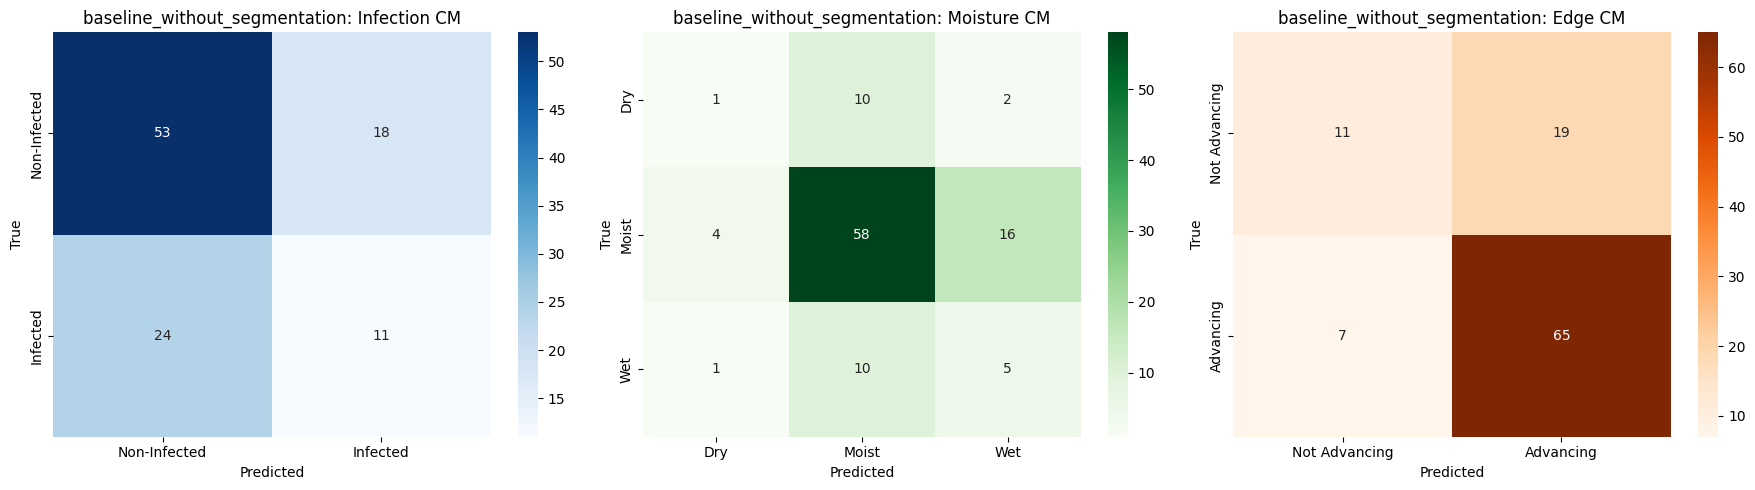

Confusion matrix figure saved to: /content/drive/MyDrive/Wound_Assessment/results/baseline_without_segmentation/baseline_without_segmentation_confusion_matrices.png

Results successfully saved to: /content/drive/MyDrive/Wound_Assessment/results/baseline_without_segmentation

--- baseline_without_segmentation Final Summary ---


In [ ]:
target_names_inf = ["Non-Infected", "Infected"]
target_names_moist = ["Dry", "Moist", "Wet"]
target_names_edge = ["Not Advancing", "Advancing"]

# Storage for global metrics across all folds
all_true_inf, all_preds_inf = [], []
all_true_moist, all_preds_moist = [], []
all_true_edge, all_preds_edge = [], []

print(f"Starting Final Evaluation for {EXPERIMENT_NAME} models...")

for fold in range(5):
    print(f"--- Evaluating Fold {fold+1}/5 ---")

    val_df = df[df['fold'] == fold].reset_index(drop=True)
    val_ds = ProposedWoundDataset(val_df, transform=data_transforms['val'])
    val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

    model = ProposedMultiTaskModel().to(DEVICE)
    model_path = os.path.join(MODEL_SAVE_DIR, f"{EXPERIMENT_NAME}_Fold{fold}.pth")

    try:
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
        model.eval()
    except FileNotFoundError:
        print(f"Warning: {model_path} not found. Skipping fold.")
        continue

    with torch.no_grad():
        for images, labels_inf, labels_moist, labels_edge in val_loader:
            images = images.to(DEVICE)

            out_inf, out_moist, out_edge = model(images)

            preds_inf = torch.argmax(out_inf, dim=1).cpu().numpy()
            preds_moist = torch.argmax(out_moist, dim=1).cpu().numpy()
            preds_edge = torch.argmax(out_edge, dim=1).cpu().numpy()

            all_true_inf.extend(labels_inf.numpy())
            all_preds_inf.extend(preds_inf)

            all_true_moist.extend(labels_moist.numpy())
            all_preds_moist.extend(preds_moist)

            all_true_edge.extend(labels_edge.numpy())
            all_preds_edge.extend(preds_edge)


def filter_missing(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != -1
    return y_true[mask], y_pred[mask]

print(f"\n{'='*20} FINAL SUPERVISED REPORT {'='*20}")

# Infection Report
clean_true_i, clean_pred_i = filter_missing(all_true_inf, all_preds_inf)
print("\nINFECTION PERFORMANCE:")
print(classification_report(
    clean_true_i, clean_pred_i,
    labels=[0, 1],
    target_names=target_names_inf,
    zero_division=0
))

# Moisture Report
clean_true_m, clean_pred_m = filter_missing(all_true_moist, all_preds_moist)
print("\nMOISTURE PERFORMANCE:")
print(classification_report(
    clean_true_m, clean_pred_m,
    labels=[0, 1, 2],
    target_names=target_names_moist,
    zero_division=0
))

# Edge Report
clean_true_e, clean_pred_e = filter_missing(all_true_edge, all_preds_edge)
print("\nEDGE PERFORMANCE:")
print(classification_report(
    clean_true_e, clean_pred_e,
    labels=[0, 1],
    target_names=target_names_edge,
    zero_division=0
))

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(
    confusion_matrix(clean_true_i, clean_pred_i, labels=[0, 1]),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=target_names_inf,
    yticklabels=target_names_inf,
    ax=axes[0]
)
axes[0].set_title(f'{EXPERIMENT_NAME}: Infection CM')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(
    confusion_matrix(clean_true_m, clean_pred_m, labels=[0, 1, 2]),
    annot=True, fmt='d', cmap='Greens',
    xticklabels=target_names_moist,
    yticklabels=target_names_moist,
    ax=axes[1]
)
axes[1].set_title(f'{EXPERIMENT_NAME}: Moisture CM')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

sns.heatmap(
    confusion_matrix(clean_true_e, clean_pred_e, labels=[0, 1]),
    annot=True, fmt='d', cmap='Oranges',
    xticklabels=target_names_edge,
    yticklabels=target_names_edge,
    ax=axes[2]
)
axes[2].set_title(f'{EXPERIMENT_NAME}: Edge CM')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('True')

plt.tight_layout()
plt.show()

# Save confusion matrix figure
cm_save_path = os.path.join(SAVE_DIR, f"{EXPERIMENT_NAME}_confusion_matrices.png")
fig.savefig(cm_save_path, dpi=300, bbox_inches='tight')
print(f"Confusion matrix figure saved to: {cm_save_path}")
print(f"\nResults successfully saved to: {SAVE_DIR}")
print(f"\n--- {EXPERIMENT_NAME} Final Summary ---")

## Calculate Medical Metrics (Sensitivity/ Specificity) & Save

In [ ]:
print(f"Generating final metric report for: {EXPERIMENT_NAME}...")


def get_medical_metrics(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    # Infection and Edge
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        accuracy = (tp + tn) / (tp + tn + fp + fn)
        return sensitivity, specificity, accuracy

    # Moisture
    acc = accuracy_score(y_true, y_pred)
    return None, None, acc


# Infection
sens_inf, spec_inf, acc_inf = get_medical_metrics(clean_true_i, clean_pred_i)
f1_inf = f1_score(clean_true_i, clean_pred_i, average='macro', zero_division=0)
recall_inf = recall_score(clean_true_i, clean_pred_i, average='macro', zero_division=0)
precision_inf = precision_score(clean_true_i, clean_pred_i, average='macro', zero_division=0)

# Moisture
_, _, acc_moist = get_medical_metrics(clean_true_m, clean_pred_m)
f1_moist = f1_score(clean_true_m, clean_pred_m, average='macro', zero_division=0)
recall_moist = recall_score(clean_true_m, clean_pred_m, average='macro', zero_division=0)
precision_moist = precision_score(clean_true_m, clean_pred_m, average='macro', zero_division=0)

# Edge
sens_edge, spec_edge, acc_edge = get_medical_metrics(clean_true_e, clean_pred_e)
f1_edge = f1_score(clean_true_e, clean_pred_e, average='macro', zero_division=0)
recall_edge = recall_score(clean_true_e, clean_pred_e, average='macro', zero_division=0)
precision_edge = precision_score(clean_true_e, clean_pred_e, average='macro', zero_division=0)

# Final results table
results_data = {
    "Metric": [
        "Accuracy",
        "Sensitivity / Recall",
        "Specificity",
        "Precision",
        "Macro F1-Score"
    ],
    "Infection": [acc_inf, sens_inf, spec_inf, precision_inf, f1_inf],
    "Moisture":  [acc_moist, recall_moist, "N/A (Multi-class)", precision_moist, f1_moist],
    "Edge":      [acc_edge, sens_edge, spec_edge, precision_edge, f1_edge]
}

results_df = pd.DataFrame(results_data)

# Round numeric values for cleaner output
for col in ["Infection", "Moisture", "Edge"]:
    results_df[col] = results_df[col].apply(
        lambda x: round(x, 4) if isinstance(x, (float, int, np.floating)) else x
    )

# Save result to experiment folder
save_filename = f'{EXPERIMENT_NAME}_Final_Metrics.csv'
save_path = os.path.join(SAVE_DIR, save_filename)
results_df.to_csv(save_path, index=False)

print(f"\nResults successfully saved to: {save_path}")
print(f"\n--- {EXPERIMENT_NAME} Final Summary ---")
print(results_df.to_string(index=False))

Generating final metric report for: baseline_without_segmentation...

Results successfully saved to: /content/drive/MyDrive/Wound_Assessment/results/baseline_without_segmentation/baseline_without_segmentation_Final_Metrics.csv

--- baseline_without_segmentation Final Summary ---
              Metric  Infection          Moisture   Edge
            Accuracy     0.6038            0.5981 0.7451
Sensitivity / Recall     0.3143            0.3777 0.9028
         Specificity     0.7465 N/A (Multi-class) 0.3667
           Precision     0.5338            0.3759 0.6925
      Macro F1-Score     0.5300            0.3684 0.6458
